Found 263 total repos matching 'stars:>10000 forks:>10000'.

Processing repos 1 through 10 (of 263)...
1. Checking repo 'freeCodeCamp/freeCodeCamp' for PRs containing 'translate readme'...
   Found 30 matching PR(s).
------------------------------------------------------------
2. Checking repo 'EbookFoundation/free-programming-books' for PRs containing 'translate readme'...
   Found 1 matching PR(s).
------------------------------------------------------------
3. Checking repo 'sindresorhus/awesome' for PRs containing 'translate readme'...
   No matching PRs found.
------------------------------------------------------------
4. Checking repo 'codecrafters-io/build-your-own-x' for PRs containing 'translate readme'...
   No matching PRs found.
------------------------------------------------------------
5. Checking repo 'public-apis/public-apis' for PRs containing 'translate readme'...
   Found 1 matching PR(s).
------------------------------------------------------------
6. Checking rep

/var/folders/69/v8ssf9pd79g5zq4xgvj02x700000gn/T/ipykernel_47864/3467246809.py:156: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["created_at"].dt.to_period("M")


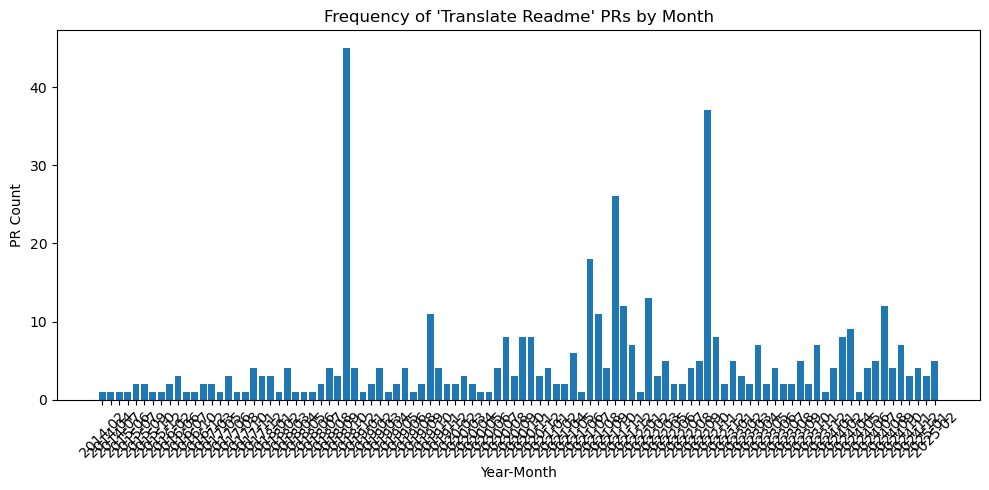

In [10]:
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your personal access token


def github_request(url, params=None):
    """
    Helper function to perform GET requests to the GitHub API,
    returning both JSON data and headers.
    """
    headers = {
       
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        response.raise_for_status()
        return response.json(), response.headers
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
        if e.response is not None:
            print(f"Response text: {e.response.text}")
        raise

def fetch_repositories(query, max_pages=5, per_page=100):
    """
    Fetch up to 'max_pages' pages of repositories matching 'query'.
    Returns a list of repo items (dict).
    """
    url = "https://api.github.com/search/repositories"
    all_items = []
    
    for page in range(1, max_pages + 1):
        params = {
            "q": query,
            "sort": "stars",
            "order": "desc",
            "per_page": per_page,
            "page": page
        }
        data, headers = github_request(url, params=params)
        items = data.get("items", [])
        
        if not items:
            break
        
        all_items.extend(items)
        
        if len(items) < per_page:
            break
        
        time.sleep(1)
    
    return all_items

def search_pull_requests_in_repo(owner, repo, pr_query="translate readme in:title is:pr",
                                 max_pages=3, per_page=30):
    """
    Searches for pull requests in a specific repo, matching pr_query.
    Returns a list of PRs (each is a dict with keys like 'title', 'html_url', etc.).
    """
    url = "https://api.github.com/search/issues"
    all_prs = []
    
    for page in range(1, max_pages + 1):
        params = {
            "q": f"repo:{owner}/{repo} {pr_query}",
            "sort": "created",
            "order": "desc",
            "per_page": per_page,
            "page": page
        }
        data, headers = github_request(url, params=params)
        
        items = data.get("items", [])
        if not items:
            break
        
        all_prs.extend(items)
        
        if len(items) < per_page:
            break
        
        time.sleep(1)
    
    return all_prs

def main():
    # 1. Search for repositories with >10k stars & forks
    repo_query = "stars:>10000 forks:>10000"
    repos = fetch_repositories(repo_query, max_pages=5, per_page=100)
    
    total_repos = len(repos)
    print(f"Found {total_repos} total repos matching '{repo_query}'.\n")

    # List to collect the creation dates of all PRs
    all_pr_dates = []

    # 2. We'll keep a global total of all PRs found
    global_pr_count = 0

    # 3. Process all repositories in batches of 10
    batch_size = 10
    for start_index in range(0, total_repos, batch_size):
        batch = repos[start_index : start_index + batch_size]
        batch_end_index = start_index + len(batch)

        print(f"Processing repos {start_index + 1} through {batch_end_index} (of {total_repos})...")

        # 4. For each repo in the current batch, search for "translate readme" PRs
        for i, repo_info in enumerate(batch, start=start_index + 1):
            full_name = repo_info.get("full_name")
            if not full_name:
                continue
            
            owner, repo_name = full_name.split("/")
            print(f"{i}. Checking repo '{full_name}' for PRs containing 'translate readme'...")

            # Fetch up to 3 pages of PRs, 30 per page => up to 90 PRs per repo
            prs = search_pull_requests_in_repo(owner, repo_name,
                                               max_pages=3, per_page=30)
            pr_count = len(prs)
            global_pr_count += pr_count

            if pr_count > 0:
                print(f"   Found {pr_count} matching PR(s).")
                for pr in prs:
                    # Extract creation date
                    creation_date_str = pr.get("created_at")
                    if creation_date_str:
                        all_pr_dates.append(creation_date_str)
            else:
                print("   No matching PRs found.")
            
            print("-" * 60)
            time.sleep(2)  # small delay to reduce risk of rate-limiting

        print("Finished this batch.\n")
        time.sleep(5)

    # 5. After all batches, print the global total of PRs
    print(f"Overall total 'translate readme' PRs found across all large repos: {global_pr_count}")

    # 6. Build a DataFrame from the collected creation dates
    if not all_pr_dates:
        print("No 'translate readme' PRs were found, so there's no data to analyze.")
        return

    df = pd.DataFrame(all_pr_dates, columns=["created_at"])
    df["created_at"] = pd.to_datetime(df["created_at"])

    # Create a Year-Month column for grouping
    df["year_month"] = df["created_at"].dt.to_period("M")

    # 7. Count PRs per Year-Month
    monthly_counts = df.groupby("year_month").size().reset_index(name="pr_count")

    # 8. Print the results as a table
    print("\n=== 'Translate Readme' PRs by Year-Month ===")
    print(monthly_counts.to_string(index=False))

    # 9. (Optional) Plot the results as a bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_counts["year_month"].astype(str), monthly_counts["pr_count"])
    plt.title("Frequency of 'Translate Readme' PRs by Month")
    plt.xlabel("Year-Month")
    plt.ylabel("PR Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



Found 57 total repos matching 'stars:5000..10000 forks:5000..10000'.

Processing repos 1 through 10 (of 57)...
1. Checking repo 'Yorko/mlcourse.ai' for PRs containing 'translate readme'...
   Found 4 matching PR(s).
------------------------------------------------------------
2. Checking repo 'Klipper3d/klipper' for PRs containing 'translate readme'...
   No matching PRs found.
------------------------------------------------------------
3. Checking repo 'TrinityCore/TrinityCore' for PRs containing 'translate readme'...
   No matching PRs found.
------------------------------------------------------------
4. Checking repo 'awsdocs/aws-doc-sdk-examples' for PRs containing 'translate readme'...
   No matching PRs found.
------------------------------------------------------------
5. Checking repo 'actions/starter-workflows' for PRs containing 'translate readme'...
   No matching PRs found.
------------------------------------------------------------
6. Checking repo 'StartBootstrap/start

/var/folders/69/v8ssf9pd79g5zq4xgvj02x700000gn/T/ipykernel_47864/2695564047.py:156: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["created_at"].dt.to_period("M")


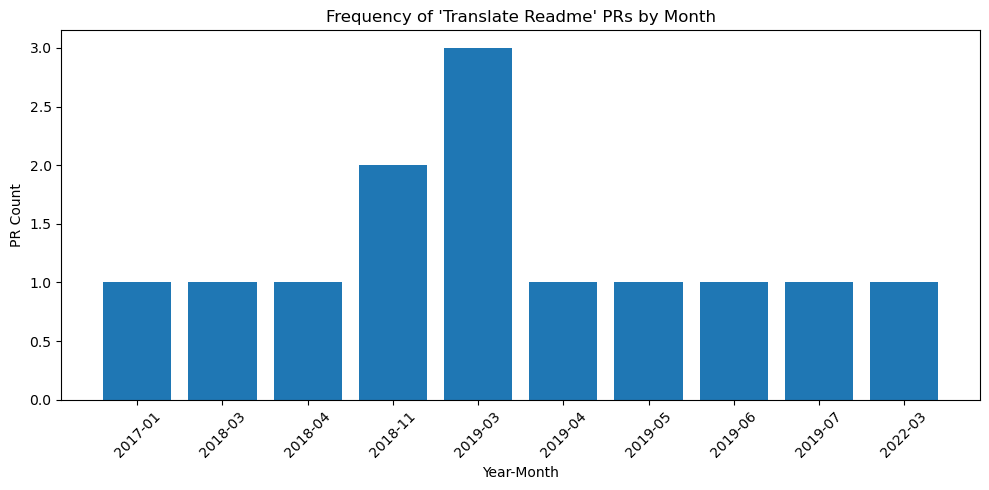

In [11]:
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your personal access token


def github_request(url, params=None):
    """
    Helper function to perform GET requests to the GitHub API,
    returning both JSON data and headers.
    """
    headers = {
        
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        response.raise_for_status()
        return response.json(), response.headers
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
        if e.response is not None:
            print(f"Response text: {e.response.text}")
        raise

def fetch_repositories(query, max_pages=5, per_page=100):
    """
    Fetch up to 'max_pages' pages of repositories matching 'query'.
    Returns a list of repo items (dict).
    """
    url = "https://api.github.com/search/repositories"
    all_items = []
    
    for page in range(1, max_pages + 1):
        params = {
            "q": query,
            "sort": "stars",
            "order": "desc",
            "per_page": per_page,
            "page": page
        }
        data, headers = github_request(url, params=params)
        items = data.get("items", [])
        
        if not items:
            break
        
        all_items.extend(items)
        
        if len(items) < per_page:
            break
        
        time.sleep(1)
    
    return all_items

def search_pull_requests_in_repo(owner, repo, pr_query="translate readme in:title is:pr",
                                 max_pages=3, per_page=30):
    """
    Searches for pull requests in a specific repo, matching pr_query.
    Returns a list of PRs (each is a dict with keys like 'title', 'html_url', etc.).
    """
    url = "https://api.github.com/search/issues"
    all_prs = []
    
    for page in range(1, max_pages + 1):
        params = {
            "q": f"repo:{owner}/{repo} {pr_query}",
            "sort": "created",
            "order": "desc",
            "per_page": per_page,
            "page": page
        }
        data, headers = github_request(url, params=params)
        
        items = data.get("items", [])
        if not items:
            break
        
        all_prs.extend(items)
        
        if len(items) < per_page:
            break
        
        time.sleep(1)
    
    return all_prs

def main():
    # 1. Search for repositories with >10k stars & forks
    repo_query = "stars:5000..10000 forks:5000..10000"
    repos = fetch_repositories(repo_query, max_pages=5, per_page=100)
    
    total_repos = len(repos)
    print(f"Found {total_repos} total repos matching '{repo_query}'.\n")

    # List to collect the creation dates of all PRs
    all_pr_dates = []

    # 2. We'll keep a global total of all PRs found
    global_pr_count = 0

    # 3. Process all repositories in batches of 10
    batch_size = 10
    for start_index in range(0, total_repos, batch_size):
        batch = repos[start_index : start_index + batch_size]
        batch_end_index = start_index + len(batch)

        print(f"Processing repos {start_index + 1} through {batch_end_index} (of {total_repos})...")

        # 4. For each repo in the current batch, search for "translate readme" PRs
        for i, repo_info in enumerate(batch, start=start_index + 1):
            full_name = repo_info.get("full_name")
            if not full_name:
                continue
            
            owner, repo_name = full_name.split("/")
            print(f"{i}. Checking repo '{full_name}' for PRs containing 'translate readme'...")

            # Fetch up to 3 pages of PRs, 30 per page => up to 90 PRs per repo
            prs = search_pull_requests_in_repo(owner, repo_name,
                                               max_pages=3, per_page=30)
            pr_count = len(prs)
            global_pr_count += pr_count

            if pr_count > 0:
                print(f"   Found {pr_count} matching PR(s).")
                for pr in prs:
                    # Extract creation date
                    creation_date_str = pr.get("created_at")
                    if creation_date_str:
                        all_pr_dates.append(creation_date_str)
            else:
                print("   No matching PRs found.")
            
            print("-" * 60)
            time.sleep(2)  # small delay to reduce risk of rate-limiting

        print("Finished this batch.\n")
        time.sleep(5)

    # 5. After all batches, print the global total of PRs
    print(f"Overall total 'translate readme' PRs found across all large repos: {global_pr_count}")

    # 6. Build a DataFrame from the collected creation dates
    if not all_pr_dates:
        print("No 'translate readme' PRs were found, so there's no data to analyze.")
        return

    df = pd.DataFrame(all_pr_dates, columns=["created_at"])
    df["created_at"] = pd.to_datetime(df["created_at"])

    # Create a Year-Month column for grouping
    df["year_month"] = df["created_at"].dt.to_period("M")

    # 7. Count PRs per Year-Month
    monthly_counts = df.groupby("year_month").size().reset_index(name="pr_count")

    # 8. Print the results as a table
    print("\n=== 'Translate Readme' PRs by Year-Month ===")
    print(monthly_counts.to_string(index=False))

    # 9. (Optional) Plot the results as a bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_counts["year_month"].astype(str), monthly_counts["pr_count"])
    plt.title("Frequency of 'Translate Readme' PRs by Month")
    plt.xlabel("Year-Month")
    plt.ylabel("PR Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

